In [5]:
import matplotlib.pyplot as plt
import numpy as np

raise NotImplementedError()
# 데이터 정의
labels = ['A5000', 'A6000', 'A100', 'RTX4090', 'H100']
pytorch_times = [35.653122, 30.154753, 17.885183, 18.035711, 9.617920]
triton_times = [18.843649, 16.788481, 12.052481, 6.987776, 5.596768]

x = np.arange(len(labels))  # 레이블 위치
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# 각 그룹에 대한 막대 생성
rects1 = ax.bar(x - width / 2, pytorch_times, width, label='PyTorch')
rects2 = ax.bar(x + width / 2, triton_times, width, label='Triton')

# 제목 및 레이블 설정
ax.set_ylabel('Time (ms)', fontsize=14)
ax.set_title('Pairformer forward time (384 crop size, bfloat16)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=12)

ax.set_ylim(0, 40)
ax.tick_params(axis='y', labelsize=12)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:2.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

for i in range(len(labels)):
    pytorch_time = pytorch_times[i]
    triton_time = triton_times[i]

    bar_x_triton = rects2[i].get_x() + rects2[i].get_width() / 2
    bar_height_triton = triton_time

    # 2. 성능 향상 정보 계산 및 표시 (Triton 시간 값 위에)
    if triton_time > 0 and pytorch_time > 0: # 유효한 데이터인 경우
        speedup_ratio = pytorch_time / triton_time
        ax.annotate(f"{speedup_ratio:.1f}x",
                    xy=(bar_x_triton, bar_height_triton),
                    xytext=(0, 20),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10,
                    color='red',
                    fontweight='bold')


fig.tight_layout()
plt.savefig('figures/pairformer_times.png')
plt.show()

NotImplementedError: 

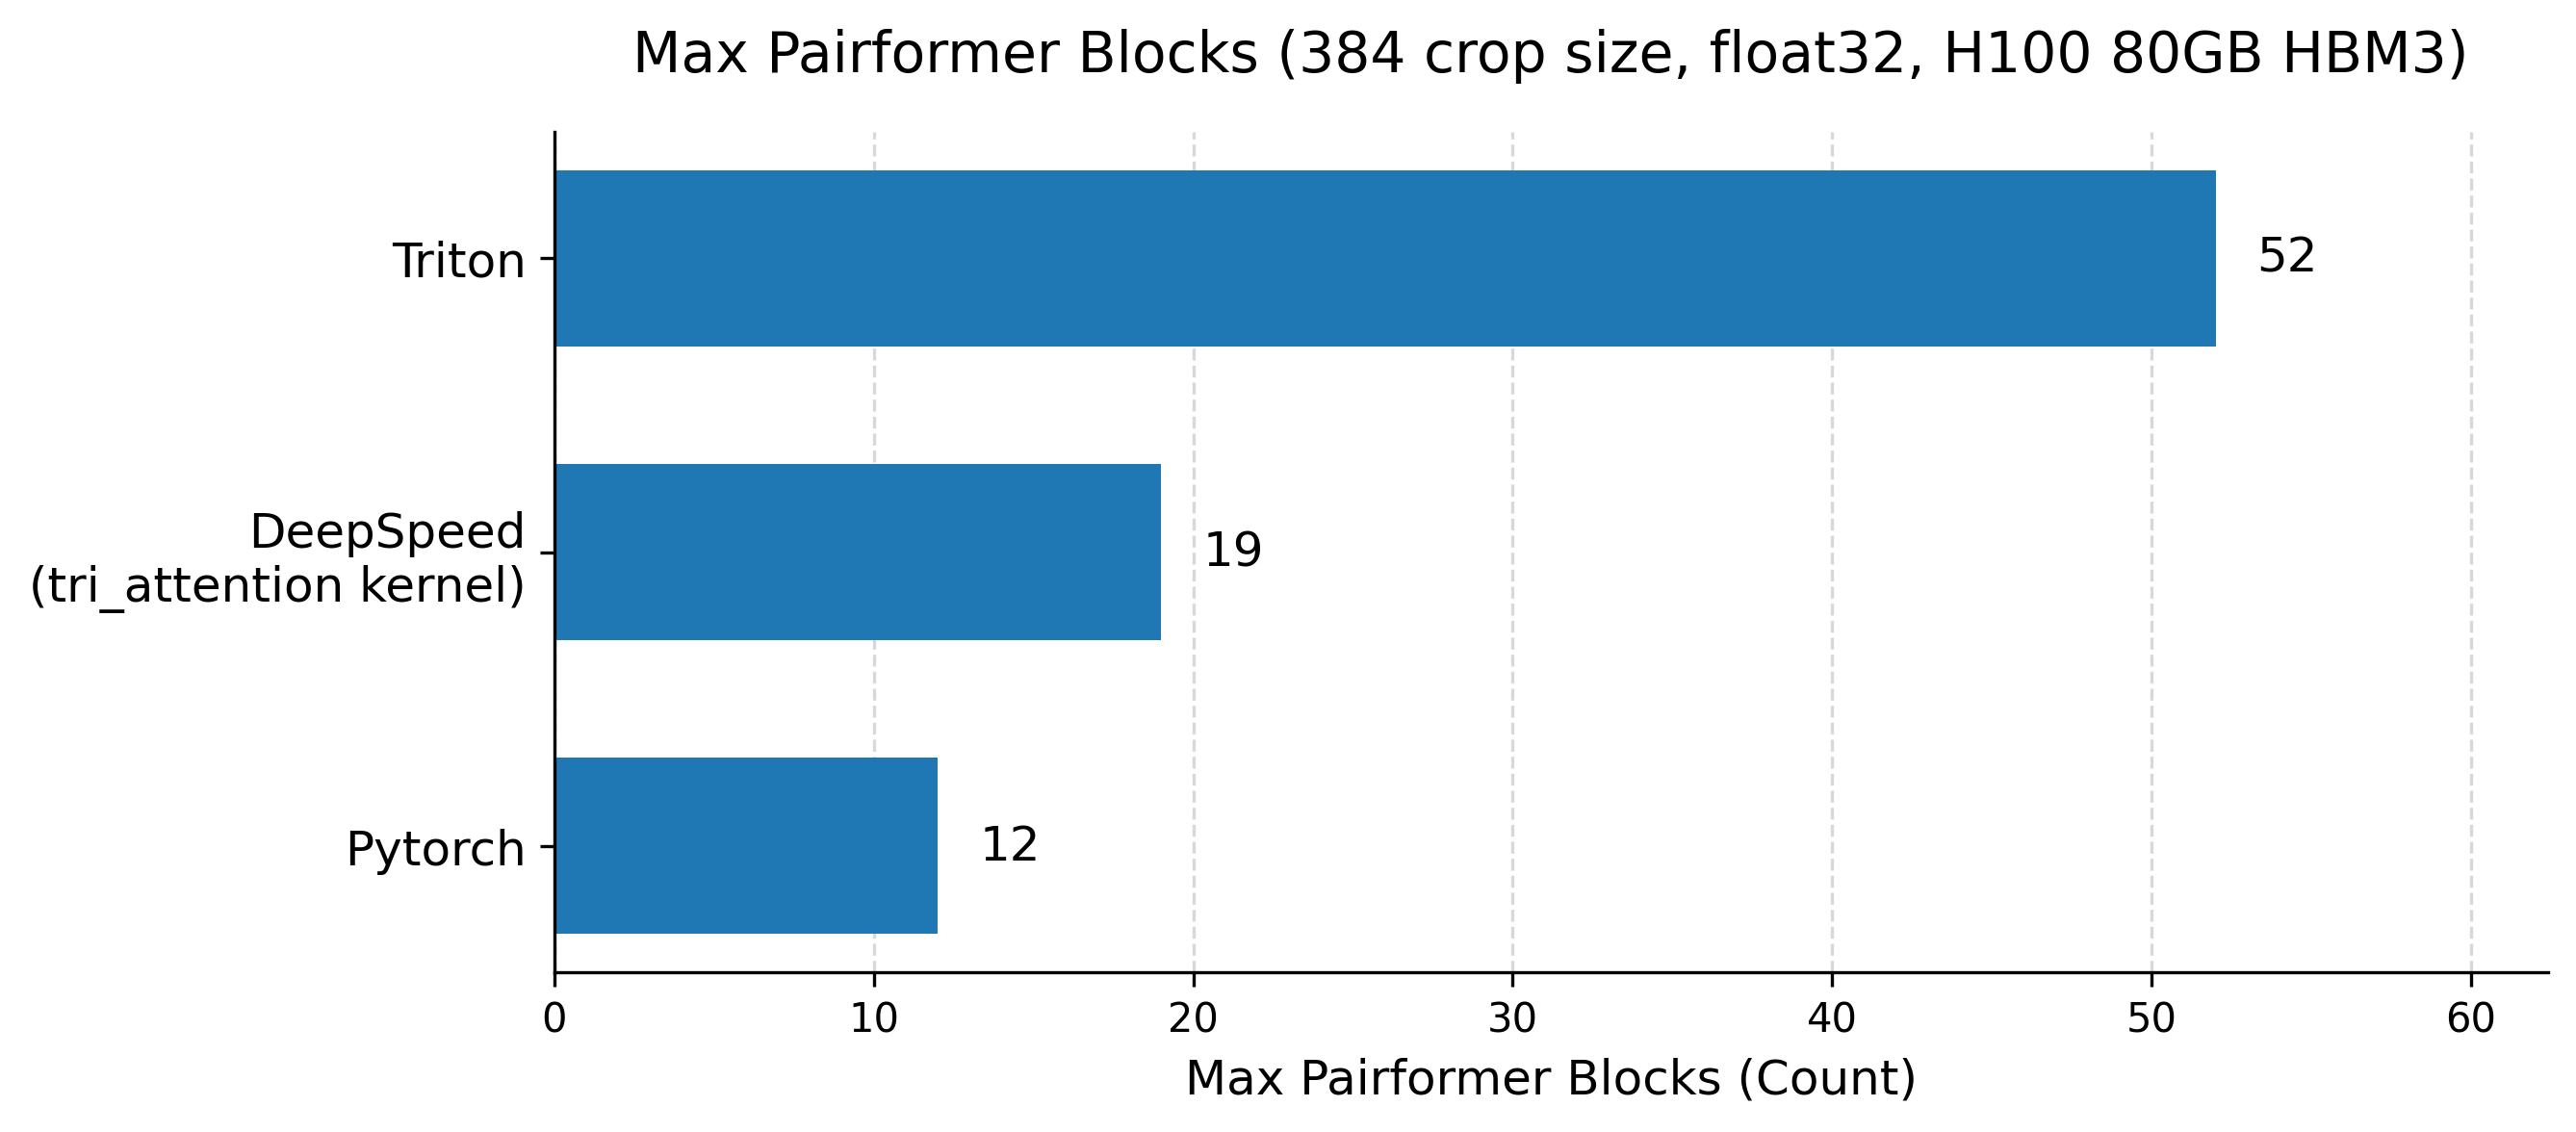

In [4]:
import matplotlib.pyplot as plt
import numpy as np


implementations_data = {
    'Triton': 52,
    'DeepSpeed\n(tri_attention kernel)': 19,
    'Pytorch': 12,
}

labels_display = list(implementations_data.keys())
max_blocks = np.array(list(implementations_data.values()))

num_items = len(labels_display)
y_pos = np.arange(num_items) 

fig, ax = plt.subplots(figsize=(9, 4), dpi=300) # 그래프 크기 (너비, 높이)

# 수평 막대 그래프 생성
bar_height = 0.6
bars = ax.barh(y_pos, max_blocks, height=bar_height, align='center')

# Y축 설정: 왼쪽에 Implementation 이름 표시
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_display, fontsize=12)
ax.invert_yaxis()  # 첫 번째 항목(가장 성능 좋은 것)을 위로 오도록 y축 반전

# X축 설정: "Max Pairformer Blocks (Count)"
ax.set_xlabel('Max Pairformer Blocks (Count)', fontsize=12)
ax.tick_params(axis='x', labelsize=10)

# X축 그리드 추가 (가독성 향상)
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True) # 그리드가 막대 뒤에 그려지도록 설정

# 그래프 제목 설정
ax.set_title('Max Pairformer Blocks (384 crop size, float32, H100 80GB HBM3)',
             fontsize=14, pad=15)

value_text_x_coord = max(max_blocks) * 1.05 # 막대 최대값의 5% 오른쪽에 텍스트 시작

for i, value in enumerate(max_blocks):
    ax.text(value + 1.3,
            y_pos[i],
            f'{value}',
            va='center',
            ha='left',
            fontsize=12,
            color='black')

ax.set_xlim(0, value_text_x_coord + max(max_blocks) * 0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig('figures/pairformer_blocks.png')
plt.show()